# Physics-Informed Machine Learning

Neural networks trained purely on data extrapolate poorly when data is sparse and noisy. In many science problems we *also* know an equation the data must (approximately) satisfy. PIML uses that equation as a soft constraint in the loss.

Two flavors:
- **Forward problem** — given the equation and a few measurements, recover the full solution (including outside the observed window).
- **Inverse problem** — given measurements, recover *both* the solution and the unknown coefficients of the equation.

We will demonstrate both on a damped pendulum.

#### [1] [Steve L. Brunton](https://www.youtube.com/@Eigensteve) - Great youtube channel
#### [2] [Raissi et. al. 2019](https://www.sciencedirect.com/science/article/pii/S0021999118307125) - Original PINN paper
#### [3] [Tancik et. Al. 2020](https://arxiv.org/pdf/2006.10739) - Fourier Features paper

## Preamble

In [2]:
from typing import Iterator

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from torch.nn import Parameter
from tqdm.notebook import trange

import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

# Pick the fastest backend available. Swap to 'cuda' or 'cpu' if needed.
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 110

Using device: mps


## The key principle: minimize the "physics loss"

![Alt Text](Brunton_PINN.png)

Our NN already takes $t$ and learns to predict $\theta_{NN}(t)$.
We can compute $\dot{\theta}_{NN}(t)$, $\ddot{\theta}_{NN}(t)$, and other quantities which we expect to carry meaningful physical significance.
Notice the physics loss is computed on a virtual set of points, which is where the strength lies, even if we have a small amount of data, **any** prediction of the network should in principle fulfill the physics constraint.
The "virtual" points are also referred to as collocation points.

## Physics-Informed Loss Functions

<details>
<summary><h3>1. Navier-Stokes (Fluid Dynamics) <a href="https://www.science.org/doi/10.1126/science.aaw4741">Raissi et. al. 2020</a></h3></summary>
Reconstruct hidden velocity and pressure fields from passive scalar observations.

**Loss:**
$$\mathcal{L} = \underbrace{\|c_{\text{pred}} - c_{\text{obs}}\|^2}_{\text{data-driven}} + \underbrace{\lambda_1 \|\partial_t c + \mathbf{u}\cdot\nabla c - \kappa\nabla^2 c\|^2}_{\text{scalar transport residual}} + \underbrace{\lambda_2 \|\text{NS residual}\|^2}_{\text{momentum residual}}$$

**Physics enforced:**

Scalar transport equation, penalized by $\lambda_1$ term:
$$\partial_t c + \mathbf{u}\cdot\nabla c = \kappa\nabla^2 c$$

Navier-Stokes momentum ( + incompressibility), penalized by $\lambda_2$ term:
$$\frac{\partial \mathbf{u}}{\partial t} + (\mathbf{u} \cdot \nabla)\mathbf{u} = -\frac{1}{\rho}\nabla p + \nu \nabla^2 \mathbf{u}, \quad \nabla \cdot \mathbf{u} = 0$$

(In the actual paper there are more terms but they amount to enforcing NS + transport)

**Parameters:**
| Symbol | Expanded Form | Meaning |
|--------|--------------|---------|
| $c_{\text{pred}}$ | — | Scalar concentration predicted by the network (e.g. dye or tracer) |
| $c_{\text{obs}}$ | — | Observed scalar concentration from imaging data |
| $\lambda_1, \lambda_2$ | — | Weighting coefficients balancing data fit vs. physics residuals |
| $\mathbf{u}$ | $(u,\, v,\, w)$ | Velocity field vector — a hidden quantity never directly observed |
| $\kappa$ | — | Molecular diffusivity of the scalar |
| $\partial_t c$ | $\dfrac{\partial c}{\partial t}$ | Rate of change of concentration in time |
| $\mathbf{u}\cdot\nabla c$ | $u\dfrac{\partial c}{\partial x} + v\dfrac{\partial c}{\partial y} + w\dfrac{\partial c}{\partial z}$ | Advection: concentration carried along by the flow |
| $\nabla^2 c$ | $\dfrac{\partial^2 c}{\partial x^2} + \dfrac{\partial^2 c}{\partial y^2} + \dfrac{\partial^2 c}{\partial z^2}$ | Laplacian: diffusion of concentration in all directions |
| $\dfrac{\partial \mathbf{u}}{\partial t}$ | $\left(\dfrac{\partial u}{\partial t},\, \dfrac{\partial v}{\partial t},\, \dfrac{\partial w}{\partial t}\right)$ | Local acceleration of the fluid |
| $(\mathbf{u}\cdot\nabla)\mathbf{u}$ | $\left(u\dfrac{\partial u}{\partial x}+v\dfrac{\partial u}{\partial y}+w\dfrac{\partial u}{\partial z},\ \ldots\right)$ | Convective acceleration — momentum carried by the flow itself |
| $\nabla p$ | $\left(\dfrac{\partial p}{\partial x},\, \dfrac{\partial p}{\partial y},\, \dfrac{\partial p}{\partial z}\right)$ | Pressure gradient driving the flow |
| $\nabla^2 \mathbf{u}$ | $\left(\dfrac{\partial^2 u}{\partial x^2}+\dfrac{\partial^2 u}{\partial y^2}+\dfrac{\partial^2 u}{\partial z^2},\ \ldots\right)$ | Viscous diffusion of momentum |
| $\rho$ | — | Fluid density |
| $p$ | — | Pressure field — hidden, inferred purely from physics |
| $\nu$ | — | Kinematic viscosity of the fluid |
| $\nabla \cdot \mathbf{u}$ | $\dfrac{\partial u}{\partial x} + \dfrac{\partial v}{\partial y} + \dfrac{\partial w}{\partial z} = 0$ | Incompressibility: no net volumetric expansion or compression |
</details>

---

<details>
<summary><h3>2. Hamiltonian Mechanics <a href="https://dl.acm.org/doi/abs/10.5555/3454287.3455665">Greydanus et. al 2019</a></h3></summary>
Learn a system's Hamiltonian so energy is conserved over long rollouts.

**Loss:**
$$\mathcal{L}_{HNN} = \left\|\dot{q} - \frac{\partial H_\theta}{\partial p}\right\|^2 + \left\|\dot{p} + \frac{\partial H_\theta}{\partial q}\right\|^2$$

**Physics enforced:**
$$\dot{q} = \frac{\partial H}{\partial p}, \quad \dot{p} = -\frac{\partial H}{\partial q}$$

**Parameters:**
| Symbol | Explicit Form | Meaning |
|--------|--------------|---------|
| $q$ | $(q_1, q_2, \ldots, q_n)$ | Generalized position coordinates (e.g. particle positions, joint angles) |
| $p$ | $(p_1, p_2, \ldots, p_n)$ | Generalized momentum coordinates |
| $\dot{q}$ | $\dfrac{dq}{dt} = \left(\dfrac{dq_1}{dt}, \ldots, \dfrac{dq_n}{dt}\right)$ | Time derivative of positions — i.e. velocities |
| $\dot{p}$ | $\dfrac{dp}{dt} = \left(\dfrac{dp_1}{dt}, \ldots, \dfrac{dp_n}{dt}\right)$ | Time derivative of momenta — i.e. generalized forces |
| $H_\theta(q,p)$ | — | Learned Hamiltonian (total energy), parametrized by the network |
| $\dfrac{\partial H_\theta}{\partial p}$ | $\left(\dfrac{\partial H_\theta}{\partial p_1}, \ldots, \dfrac{\partial H_\theta}{\partial p_n}\right)$ | Gradient of energy w.r.t. momenta — yields velocities |
| $\dfrac{\partial H_\theta}{\partial q}$ | $\left(\dfrac{\partial H_\theta}{\partial q_1}, \ldots, \dfrac{\partial H_\theta}{\partial q_n}\right)$ | Gradient of energy w.r.t. positions — yields forces (with minus sign) |
</details>

---

There are many more examples, let's focus on a specific one:

## The usual: damped harmonic oscillator ([Ben Moseley's blog](https://benmoseley.blog/my-research/so-what-is-a-physics-informed-neural-network/))

![Alt Text](oscillator.gif)

$$m\ddot{x}(t) + kx(t) + b\dot{x}(t) = 0$$

Solvable even if architecture is not the best, we can do better

## Let's try solving a $\color{red}\text{forced}$ damped $\color{orange}\text{nonlinear}$ pendulum

![Alt Text](pendulum.gif)

$$\ddot{\theta}(t) + \color{red}{F(t)}\color{white} + \frac{g}{L}\color{orange}\sin\bigl(\theta(t)\bigr)\color{white} + b\,\dot{\theta}(t) = 0$$

Two physical parameters: $g/L$ (gravity over length) and $b$ (friction coefficient) and F(t) is a driving force. Initial conditions: $\theta(0)=0$ rad, $\dot{\theta}(0)=0$.

We pick this because it is intuitive (child on a swing + swinging parent) and nonlinear (the $\sin\theta$ term). The same recipe applies unchanged to PDEs with spatial derivatives.

$$\ddot{\theta}(t) + F(t) + \frac{g}{L}\sin\bigl(\theta(t)\bigr) + b\,\dot{\theta}(t) = 0$$


## The Data

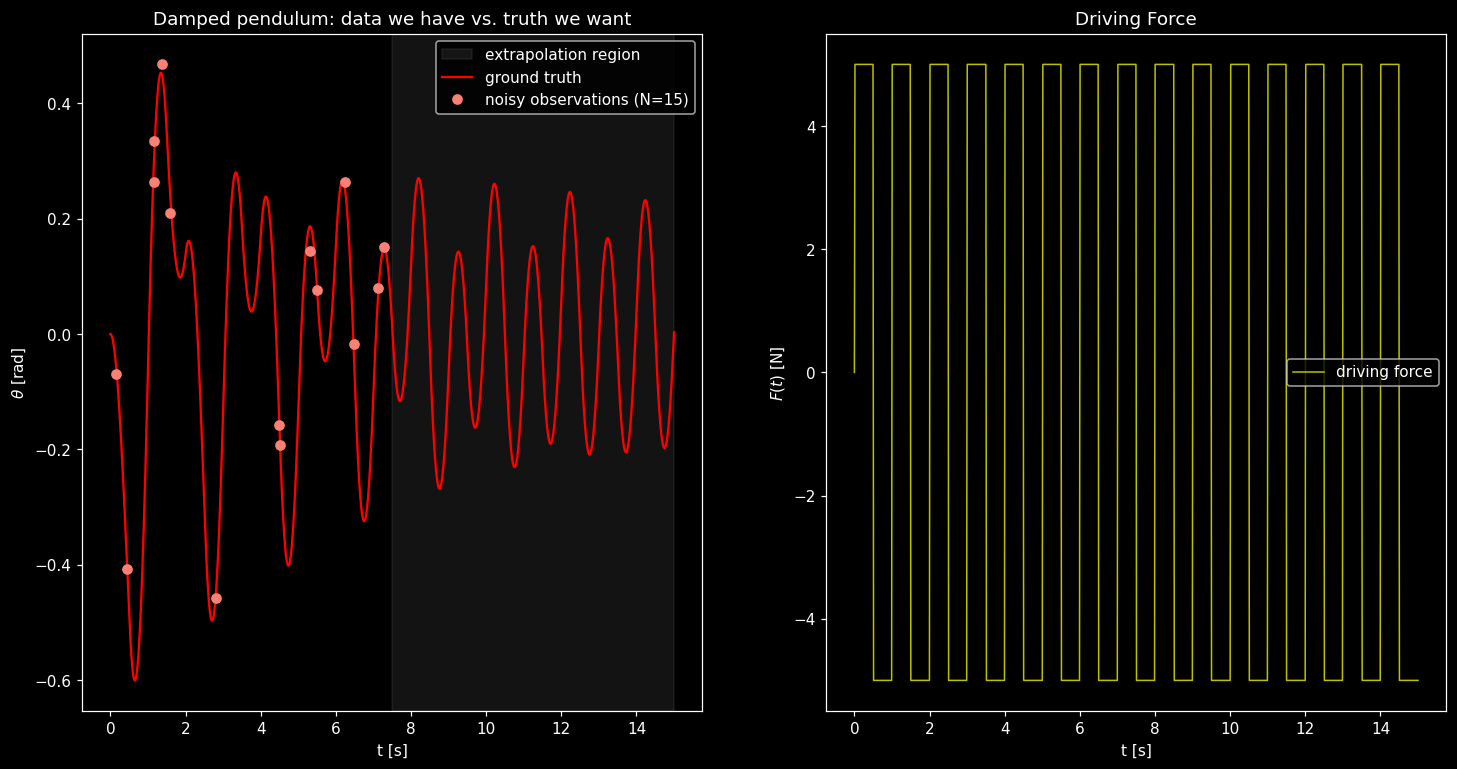

In [3]:
# True parameters (used to generate "ground truth"; in a real experiment we would not know these)
g_over_L_true = 9.0
b_true = 0.4

# Driving force: square wave with amplitude F_amp [rad/s^2] and frequency F_freq [Hz]
F_amp = 5
F_freq = 1
def F_drive_np(t):
    return F_amp * np.sign(np.sin(2 * np.pi * F_freq * t))

# Time domain
T_total = 15.0          # full simulation window (seconds)
T_obs   = 7.5           # we only observe data in [0, T_obs]; [T_obs, T_total] is extrapolation

# ODE for solve_ivp: state = [theta, theta_dot]
def pendulum_rhs(t, y, g_over_L, b):
    theta, theta_dot = y
    return [theta_dot, -g_over_L * np.sin(theta) - b * theta_dot - F_drive_np(t)]

t_dense = np.linspace(0, T_total, 1000)
sol = solve_ivp(pendulum_rhs, (0, T_total), [0, 0.0],
                t_eval=t_dense, args=(g_over_L_true, b_true), rtol=1e-8)
theta_true = sol.y[0]

# Sparse, noisy observations only in [0, T_obs]
N_obs = 15        # Very few observations !!
noise_std = 0.02  # Simulate measurement noise
t_obs = np.sort(np.random.uniform(0, T_obs, size=N_obs))
theta_obs_clean = np.interp(t_obs, t_dense, theta_true)
theta_obs = theta_obs_clean + np.random.normal(0, noise_std, size=N_obs)

# Plot
fig, axes = plt.subplots(1, 2, figsize = (16, 8))

signal_ax = axes[0]
force_ax = axes[1]

signal_ax.axvspan(T_obs, T_total, color='gray', alpha=0.15, label='extrapolation region')
signal_ax.plot(t_dense, theta_true, 'r-', lw=1.5, label='ground truth')
signal_ax.plot(t_obs, theta_obs, 'o', color='C3', label=f'noisy observations (N={N_obs})')
signal_ax.set_xlabel('t [s]')
signal_ax.set_ylabel(r'$\theta$ [rad]')
signal_ax.set_title('Damped pendulum: data we have vs. truth we want')
signal_ax.legend()

force_ax.plot(t_dense, F_drive_np(t_dense), 'y-', lw=1, label='driving force')

force_ax.set_xlabel('t [s]')
force_ax.set_ylabel(r'$F(t)$ [N]')
force_ax.set_title('Driving Force')
force_ax.legend()

plt.show()

## The model

A small MLP from $t \to \theta(t)$.
The baseline and the PINN below share the same architecture — they only differ in the loss.

In [4]:
class MLP(nn.Module):
    def __init__(self, t_max=T_total, hidden=128, n_layers=3):
        super().__init__()
        self.t_max = t_max
        layers = [nn.Linear(1, hidden), nn.Tanh()]  ## Activation is Tanh, why not ReLU ?
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        # internal rescaling: t in [0, T_total] -> [-1, 1]
        t_scaled = 2.0 * t / self.t_max - 1.0
        return self.net(t_scaled)

    def get_parameter_count(self):
        return sum(p.numel() for p in self.parameters())


# Tensors on device
t_obs_t     = torch.tensor(t_obs, dtype=torch.float32, device=device).unsqueeze(1)
theta_obs_t = torch.tensor(theta_obs, dtype=torch.float32, device=device).unsqueeze(1)
t_full_t    = torch.tensor(t_dense, dtype=torch.float32, device=device).unsqueeze(1)

## Baseline: data-only

Fit $t \mapsto \theta(t)$ with MSE on the observations. No physics.

Baseline model has 33409 parameters


baseline:   0%|          | 0/5000 [00:00<?, ?it/s]

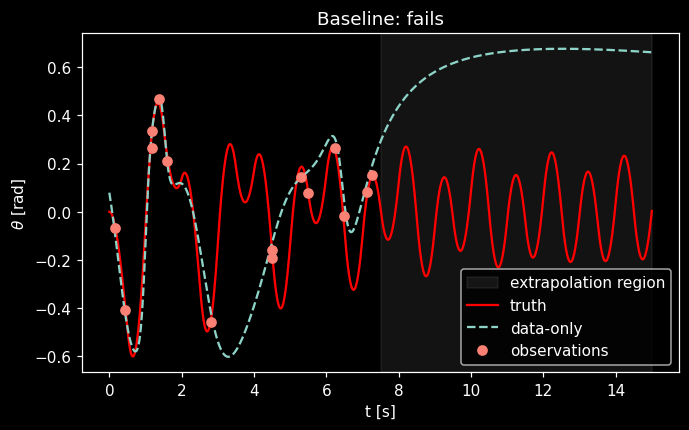

In [5]:
model_baseline = MLP().to(device)
print(f"Baseline model has {model_baseline.get_parameter_count()} parameters")
opt = torch.optim.Adam(model_baseline.parameters(), lr=1e-3)

losses_baseline = []
for step in trange(5000, desc='baseline'):
    opt.zero_grad()
    loss = ((model_baseline(t_obs_t) - theta_obs_t) ** 2).mean()
    loss.backward()
    opt.step()
    losses_baseline.append(loss.item())

with torch.no_grad():
    theta_pred_baseline = model_baseline(t_full_t).cpu().numpy().squeeze()

fig, ax = plt.subplots()
ax.axvspan(T_obs, T_total, color='gray', alpha=0.15, label='extrapolation region')
ax.plot(t_dense, theta_true, 'r-', lw=1.5, label='truth')
ax.plot(t_dense, theta_pred_baseline, 'C0--', lw=1.5, label='data-only')
ax.plot(t_obs, theta_obs, 'o', color='C3', label='observations')
ax.set_xlabel('t [s]'); ax.set_ylabel(r'$\theta$ [rad]')
ax.set_title('Baseline: fails')
ax.legend()
plt.show()

## Adding physics: the residual loss

The residual is :


$$r(t) \;=\; \ddot\theta_{NN}(t) + \frac{g}{L}\sin\bigl(\theta_{NN}(t)\bigr) + b\,\dot\theta_{NN}(t) + F(t)$$


The pendulum equation says that for the *true* solution $\theta(t)$, the residual is identically zero. We turn this into a loss term.

Given the network output $\theta_\mathrm{NN}(t)$, we get $\dot\theta_\mathrm{NN}$ and $\ddot\theta_\mathrm{NN}$ via `torch.autograd.grad`. The total loss is

$$\mathcal{L} \;=\; \mathcal{L}_\mathrm{data} \;+\; \lambda\,\mathcal{L}_\mathrm{physics}$$

with $\mathcal{L}_\mathrm{physics} = \mathrm{mean}\,r(t_i)^2$ on **collocation points** $t_i$ sampled across the *full* domain — including the extrapolation region. The physics term has no labels; it just penalizes any solution that violates the ODE.

<details>
<summary>`torch.autograd.grad`</summary>

## `torch.autograd.grad` , see [docs](https://docs.pytorch.org/docs/2.11/generated/torch.autograd.grad.html#torch.autograd.grad)

Computes gradients of `outputs` w.r.t. `inputs` and **returns them as tensors** directly,
rather than accumulating into `.grad`. Essential for PINNs where derivatives appear
explicitly inside the loss function.

**Signature:**
```python
torch.autograd.grad(outputs, inputs, grad_outputs=None,
                    retain_graph=None, create_graph=False,
                    allow_unused=False)
```

**Inputs:**

| Argument | Meaning |
|---|---|
| `outputs` | Tensor to differentiate (e.g. network output $u_\theta$) |
| `inputs` | Tensor to differentiate w.r.t. (e.g. coordinates $x, t$) |
| `grad_outputs` | Scales outputs before differentiating; defaults to ones for scalar outputs |
| `retain_graph` | Keep computation graph alive for multiple backward passes |
| `create_graph` | Make the gradient itself differentiable — **required for higher-order derivatives** |
| `allow_unused` | Return `None` instead of error if an input doesn't affect the output |

**Output:** A tuple of tensors $\left(\dfrac{\partial \text{out}}{\partial \text{in}_1},\ \dfrac{\partial \text{out}}{\partial \text{in}_2},\ \ldots\right)$
</details>

> `create_graph=True` is required at every level where you intend to
> differentiate again. Without it the graph is freed and the next call will error.


In [6]:
def derivatives(model, t):
    """Return theta, theta_dot, theta_ddot at points t. t must require grad."""
    theta = model(t)
    theta_dot = torch.autograd.grad(theta, t,
                                    grad_outputs=torch.ones_like(theta),
                                    create_graph=True)[0]  # [0] because grad returns a tuple of tensors
    theta_ddot = torch.autograd.grad(theta_dot, t,
                                     grad_outputs=torch.ones_like(theta_dot),
                                     create_graph=True)[0]
    return theta, theta_dot, theta_ddot

## If we had multiple variables we could do:
#   u_x, u_t = torch.autograd.grad(u, [x, t],
#                                    grad_outputs=torch.ones_like(u),
#                                    create_graph=True)
#   unpacking 2 elements from the tuple — no [0] needed

def F_drive(t):
    return F_amp * torch.sign(torch.sin(2 * torch.pi * F_freq * t))


def physics_residual(model, t, g_over_L, b):
    theta, theta_dot, theta_ddot = derivatives(model, t)
    return theta_ddot + g_over_L * torch.sin(theta) + b * theta_dot + F_drive(t)

## PINN training (forward problem)

True $g/L$ and $b$ are *given* — we are solving for $\theta(t)$, including in the extrapolation region.

Here we also introduce the collocation points. In principle there are several sampling strategies that may impact our results<sup>[[^]](https://www.sciencedirect.com/science/article/pii/S277241582400018X)</sup>, in our case a simple uniform sampling on [0, T_total] is good enough.

In [7]:
def train_PINN(model, opt, N_coll = 200, lambda_phys = 0.1 , n_steps = 5000):
    losses_data, losses_phys = [], []
    for step in trange(n_steps, desc='PINN'):
        opt.zero_grad()

        # data loss
        L_data = ((model(t_obs_t) - theta_obs_t) ** 2).mean()

        # physics loss on resampled collocation points
        t_coll = torch.rand(N_coll, 1, device=device) * T_total
        t_coll.requires_grad_(True)
        r = physics_residual(model, t_coll, g_over_L_true, b_true)
        L_phys = (r ** 2).mean()

        loss = L_data + lambda_phys * L_phys
        loss.backward()
        opt.step()

        losses_data.append(L_data.item())
        losses_phys.append(L_phys.item())
    return losses_data, losses_phys

lambda_1 = 0.1
model_pinn = MLP().to(device)
opt = torch.optim.Adam(model_pinn.parameters(), lr=1e-3)
losses_data, losses_phys = train_PINN(model_pinn, opt, lambda_phys = lambda_1)

PINN:   0%|          | 0/5000 [00:00<?, ?it/s]

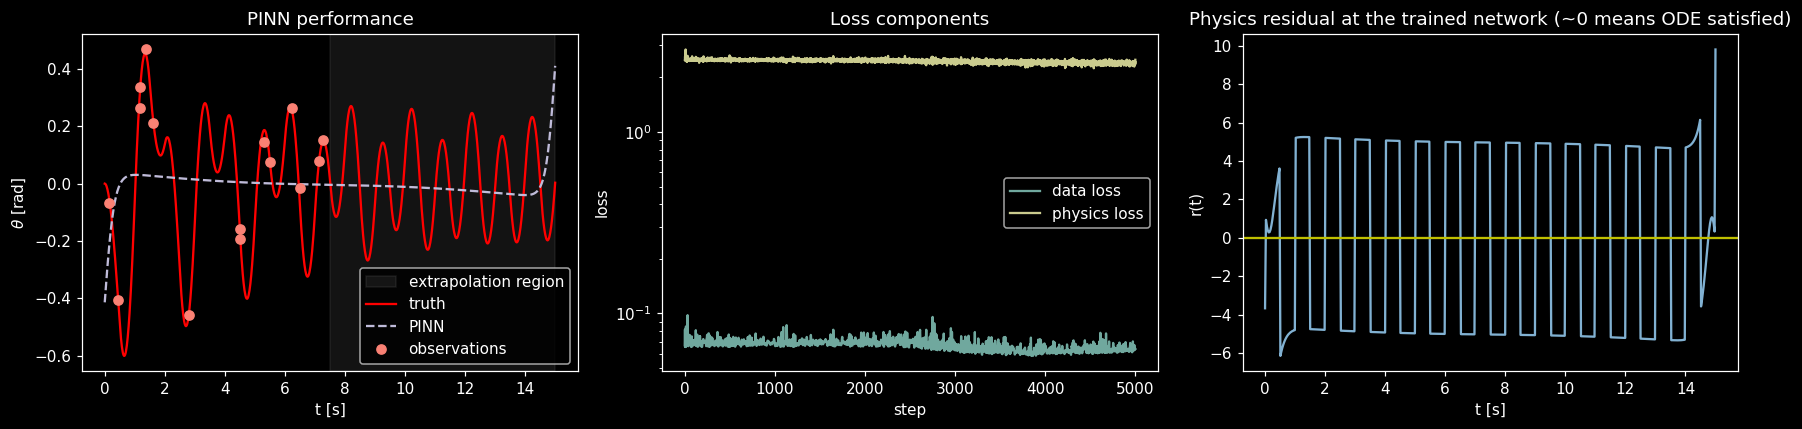

In [8]:
# Predictions over the full window
with torch.no_grad():
    theta_pred_pinn = model_pinn(t_full_t).cpu().numpy().squeeze()

def plot_pinn(theta_pred, theta_true, losses_data, losses_phys, T_total = 15.0 , T_obs = 7.5):
    # Residual on a fine grid (needs grad to compute derivatives)
    t_grid = torch.linspace(0, T_total, 500, device=device).unsqueeze(1).requires_grad_(True)
    r_grid = physics_residual(model_pinn, t_grid, g_over_L_true, b_true).detach().cpu().numpy().squeeze()
    t_grid_np = t_grid.detach().cpu().numpy().squeeze()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.axvspan(T_obs, T_total, color='gray', alpha=0.15, label='extrapolation region')
    ax.plot(t_dense, theta_true, 'r-', lw=1.5, label='truth')
    ax.plot(t_dense, theta_pred, 'C2--', lw=1.5, label='PINN')
    ax.plot(t_obs, theta_obs, 'o', color='C3', label='observations')
    ax.set_xlabel('t [s]'); ax.set_ylabel(r'$\theta$ [rad]')
    ax.set_title('PINN performance')
    ax.legend()

    ax = axes[1]
    ax.semilogy(losses_data, label='data loss', alpha=0.8)
    ax.semilogy(losses_phys, label='physics loss', alpha=0.8)
    ax.set_xlabel('step')
    ax.set_ylabel('loss')
    ax.set_title('Loss components')
    ax.legend()

    ax = axes[2]
    ax.plot(t_grid_np, r_grid, 'C4-')
    ax.axhline(0, color='y', lw=1.5)
    ax.set_xlabel('t [s]')
    ax.set_ylabel('r(t)')
    ax.set_title('Physics residual at the trained network (~0 means ODE satisfied)')

    plt.tight_layout()
    plt.show()

scaled_loss = [losses_phys[i] * lambda_1 for i in range(len(losses_phys))]
plot_pinn(theta_pred_pinn, theta_true, losses_data, scaled_loss)

## What went wrong?

Vanilla MLPs "prefer" smooth, low-frequency functions and struggle to fit oscillations cleanly<sup>[[3]](https://arxiv.org/pdf/2006.10739)</sup>. Our pendulum has many oscillations across the window — well into the regime where a plain tanh MLP does poorly.

A standard fix is to feed the network a **Fourier feature embedding** instead of raw $t$:

$$t \;\mapsto\; \bigl[\sin(\pi t/T),\,\cos(\pi t/T),\,\sin(2\pi t/T),\,\cos(2\pi t/T),\,\dots\bigr]$$

Same MLP behind it, just a more expressive input representation. Oscillatory functions become easy to represent.

In [9]:
class FourierMLP(nn.Module):
    def __init__(self, t_max=T_total, n_freqs=10, hidden=64, n_layers=3):
        super().__init__()
        self.t_max = t_max
        # fixed (non-learned) frequencies: pi, 2*pi, ..., n_freqs*pi
        freqs = torch.arange(1, n_freqs + 1, dtype=torch.float32) * np.pi
        self.register_buffer('freqs', freqs)

        layers = [nn.Linear(2 * n_freqs, hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        ang = (t / self.t_max) * self.freqs       # (B, n_freqs)
        feats = torch.cat([torch.sin(ang), torch.cos(ang)], dim=-1)
        return self.net(feats)

    def get_parameter_count(self):
        return sum(p.numel() for p in self.parameters())


In [10]:
fourier_mlp = FourierMLP().to(device)
print(f"Fourier version has {fourier_mlp.get_parameter_count()} parameters")
opt = torch.optim.Adam(fourier_mlp.parameters(), lr=1e-3)
losses_data, losses_phys = train_PINN(fourier_mlp, opt, lambda_phys=lambda_1)

Fourier version has 9729 parameters


PINN:   0%|          | 0/5000 [00:00<?, ?it/s]

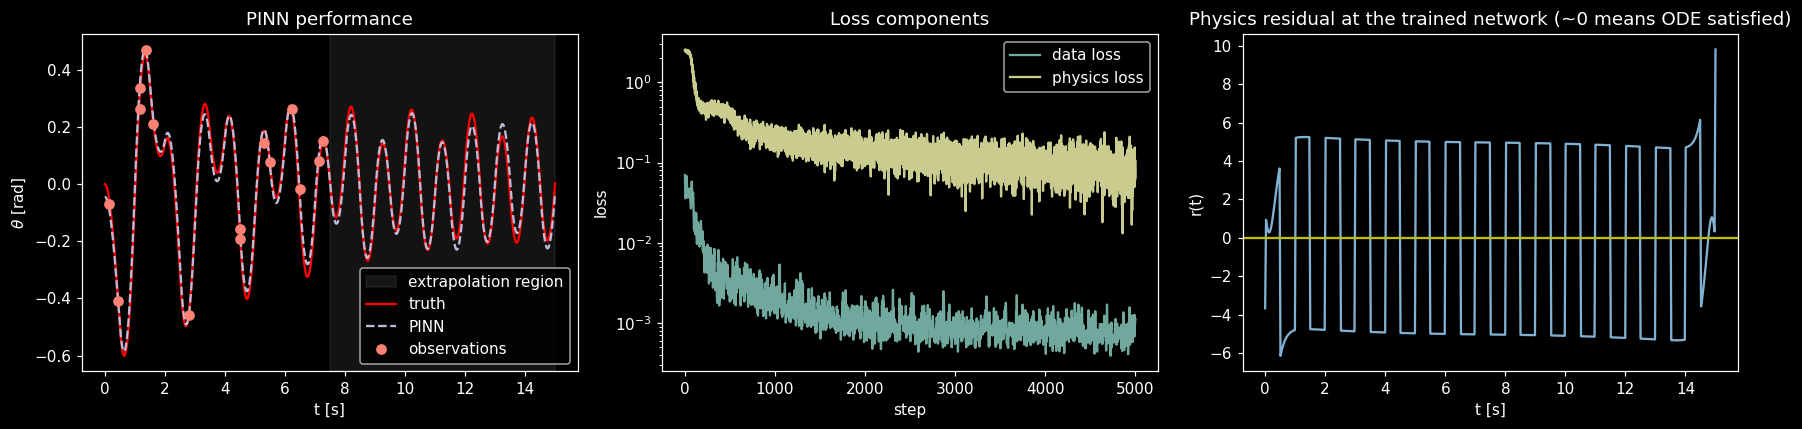

In [11]:
with torch.no_grad():
    theta_pred_fourier = fourier_mlp(t_full_t).cpu().numpy().squeeze()

scaled_loss = [losses_phys[i] * lambda_1 for i in range(len(losses_phys))]
plot_pinn(theta_pred_fourier, theta_true, losses_data, scaled_loss)

## Inverse problem: discover $g/L$ and $b$ from data

Now imagine you only have the noisy observations and you do *not* know $g/L$ or $b$. The exact same loss works — just promote the parameters to learnable tensors and add them to the optimizer.

Practical detail: we learn $\log(g/L)$ and $\log(b)$ instead of the values directly, so they stay positive and the gradient magnitudes are well-behaved. We also give them a slightly larger learning rate than the network weights.

In [12]:
# Re-seed so this cell is reproducible on its own
torch.manual_seed(0)

model_inv = MLP().to(device)
N_coll = 200
lambda_phys = 0.1  ## This will give similar scale issue as we saw previously!

# Initialize parameters far from truth (truth is 9.0 and 0.4)
log_g_over_L = nn.Parameter(torch.log(torch.tensor(3.0, device=device)))
log_b        = nn.Parameter(torch.log(torch.tensor(0.05, device=device)))

# Separate learning rates: physical params sometimes benefit from a faster lr than network weights
opt = torch.optim.Adam([
    {'params': model_inv.parameters(), 'lr': 1e-3},
    {'params': [log_g_over_L, log_b],  'lr': 5e-3},
])

n_steps = 5000
g_history, b_history = [], []
for step in trange(n_steps, desc='inverse'):
    opt.zero_grad()

    g_over_L = torch.exp(log_g_over_L)
    b        = torch.exp(log_b)

    L_data = ((model_inv(t_obs_t) - theta_obs_t) ** 2).mean()

    t_coll = torch.rand(N_coll, 1, device=device) * T_total
    t_coll.requires_grad_(True)
    r = physics_residual(model_inv, t_coll, g_over_L, b)
    L_phys = (r ** 2).mean()

    loss = L_data + lambda_phys * L_phys
    loss.backward()
    opt.step()

    g_history.append(g_over_L.item())
    b_history.append(b.item())

print(f'Recovered g/L = {g_history[-1]:.3f}   (truth: {g_over_L_true})')
print(f'Recovered b   = {b_history[-1]:.3f}   (truth: {b_true})')

inverse:   0%|          | 0/5000 [00:00<?, ?it/s]

Recovered g/L = 2.692   (truth: 9.0)
Recovered b   = 0.021   (truth: 0.4)


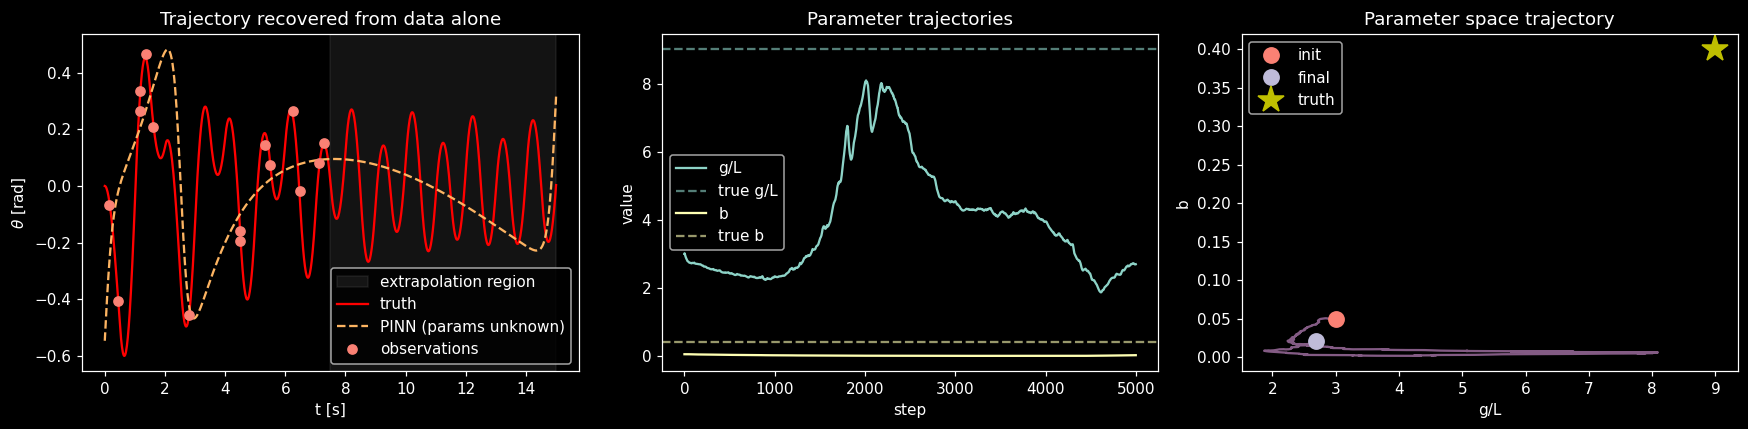

In [13]:
with torch.no_grad():
    theta_pred_inv = model_inv(t_full_t).cpu().numpy().squeeze()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.axvspan(T_obs, T_total, color='gray', alpha=0.15, label='extrapolation region')
ax.plot(t_dense, theta_true, 'r-', lw=1.5, label='truth')
ax.plot(t_dense, theta_pred_inv, 'C5--', lw=1.5, label='PINN (params unknown)')
ax.plot(t_obs, theta_obs, 'o', color='C3', label='observations')
ax.set_xlabel('t [s]'); ax.set_ylabel(r'$\theta$ [rad]')
ax.set_title('Trajectory recovered from data alone')
ax.legend()

ax = axes[1]
ax.plot(g_history, label='g/L', color='C0')
ax.axhline(g_over_L_true, color='C0', linestyle='--', alpha=0.6, label='true g/L')
ax.plot(b_history, label='b', color='C1')
ax.axhline(b_true, color='C1', linestyle='--', alpha=0.6, label='true b')
ax.set_xlabel('step'); ax.set_ylabel('value')
ax.set_title('Parameter trajectories')
ax.legend()

ax = axes[2]
ax.plot(g_history, b_history, '-', color='C7', alpha=0.7)
ax.plot(g_history[0], b_history[0], 'o', color='C3', markersize=10, label='init')
ax.plot(g_history[-1], b_history[-1], 'o', color='C2', markersize=10, label='final')
ax.plot(g_over_L_true, b_true, '*', color='y', markersize=18, label='truth')
ax.set_xlabel('g/L'); ax.set_ylabel('b')
ax.set_title('Parameter space trajectory')
ax.legend()

plt.tight_layout(); plt.show()

## Inverse problem, take two — with Fourier features

Same loss, same optimizer setup, same initialization for the unknown parameters. Only the architecture has changed.

In [14]:
torch.manual_seed(0)
lambda_phys = 0.1
model_inv_f = FourierMLP().to(device)

log_g_over_L = nn.Parameter(torch.log(torch.tensor(3.0, device=device)))
log_b        = nn.Parameter(torch.log(torch.tensor(0.05, device=device)))

opt = torch.optim.Adam([
    {'params': model_inv_f.parameters(), 'lr': 1e-3},
    {'params': [log_g_over_L, log_b],    'lr': 5e-3},  # Lower dim space, often benefits from higher LR
])

# compare to usual optimizer : opt = torch.optim.Adam(model.parameters(), lr=1e-3)

n_steps = 5000
g_history_f, b_history_f = [], []
for step in trange(n_steps, desc='inverse (Fourier)'):
    opt.zero_grad()

    g_over_L = torch.exp(log_g_over_L)
    b        = torch.exp(log_b)

    L_data = ((model_inv_f(t_obs_t) - theta_obs_t) ** 2).mean()

    t_coll = torch.rand(N_coll, 1, device=device) * T_total
    t_coll.requires_grad_(True)
    r = physics_residual(model_inv_f, t_coll, g_over_L, b)
    L_phys = (r ** 2).mean()

    loss = L_data + lambda_phys * L_phys
    loss.backward()
    opt.step()

    g_history_f.append(g_over_L.item())
    b_history_f.append(b.item())

print(f'Recovered g/L = {g_history_f[-1]:.3f}   (truth: {g_over_L_true})')
print(f'Recovered b   = {b_history_f[-1]:.3f}   (truth: {b_true})')

inverse (Fourier):   0%|          | 0/5000 [00:00<?, ?it/s]

Recovered g/L = 3.181   (truth: 9.0)
Recovered b   = 0.272   (truth: 0.4)


In [16]:
print(model_inv_f.state_dict())

OrderedDict({'freqs': tensor([ 3.1416,  6.2832,  9.4248, 12.5664, 15.7080, 18.8496, 21.9911, 25.1327,
        28.2743, 31.4159], device='mps:0'), 'net.0.weight': tensor([[-0.0214,  0.1149, -0.1192,  ...,  0.1677, -0.0744, -0.0733],
        [ 0.1041,  0.2020, -0.0026,  ...,  0.1531,  0.1434,  0.2557],
        [ 0.0298, -0.1167, -0.0217,  ..., -0.2173, -0.1817, -0.4814],
        ...,
        [ 0.1196,  0.0081,  0.0091,  ..., -0.0232,  0.2425, -0.5355],
        [-0.1793,  0.0961,  0.0416,  ..., -0.2064,  0.1078,  0.3167],
        [-0.2363,  0.0051,  0.1357,  ...,  0.1953,  0.2566,  0.2338]],
       device='mps:0'), 'net.0.bias': tensor([-1.3989e-01,  7.4777e-03,  1.4521e-03,  2.4672e-02,  1.0711e-01,
        -7.7252e-02, -5.1275e-03,  1.3575e-01, -6.7703e-02, -8.6380e-02,
         1.0893e-01,  1.7126e-01, -7.8344e-02, -5.7011e-02, -1.0670e-01,
        -9.2416e-02,  1.1414e-01, -8.5887e-02,  2.0461e-01, -2.0041e-01,
         1.0668e-02, -6.1025e-02,  6.3643e-02,  1.5650e-01,  1.4473e-01,
 

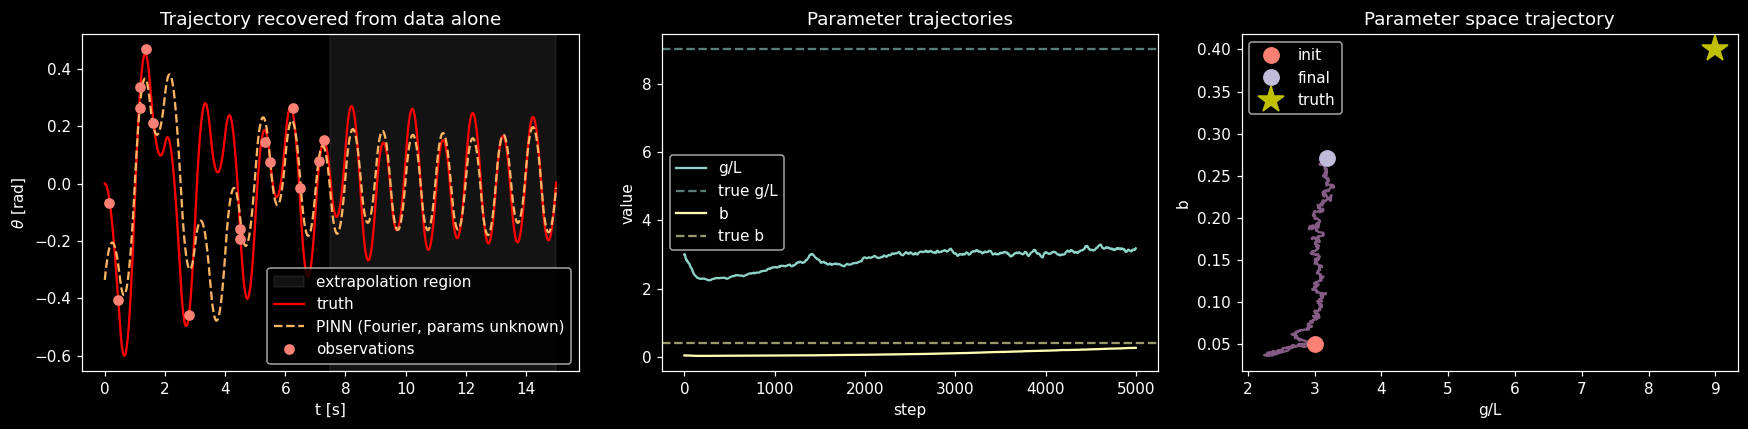

In [15]:
with torch.no_grad():
    theta_pred_inv_f = model_inv_f(t_full_t).cpu().numpy().squeeze()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.axvspan(T_obs, T_total, color='gray', alpha=0.15, label='extrapolation region')
ax.plot(t_dense, theta_true, 'r-', lw=1.5, label='truth')
ax.plot(t_dense, theta_pred_inv_f, 'C5--', lw=1.5, label='PINN (Fourier, params unknown)')
ax.plot(t_obs, theta_obs, 'o', color='C3', label='observations')
ax.set_xlabel('t [s]'); ax.set_ylabel(r'$\theta$ [rad]')
ax.set_title('Trajectory recovered from data alone')
ax.legend()

ax = axes[1]
ax.plot(g_history_f, label='g/L', color='C0')
ax.axhline(g_over_L_true, color='C0', linestyle='--', alpha=0.6, label='true g/L')
ax.plot(b_history_f, label='b', color='C1')
ax.axhline(b_true, color='C1', linestyle='--', alpha=0.6, label='true b')
ax.set_xlabel('step'); ax.set_ylabel('value')
ax.set_title('Parameter trajectories')
ax.legend()

ax = axes[2]
ax.plot(g_history_f, b_history_f, '-', color='C7', alpha=0.7)
ax.plot(g_history_f[0], b_history_f[0], 'o', color='C3', markersize=10, label='init')
ax.plot(g_history_f[-1], b_history_f[-1], 'o', color='C2', markersize=10, label='final')
ax.plot(g_over_L_true, b_true, '*', color='y', markersize=18, label='truth')
ax.set_xlabel('g/L'); ax.set_ylabel('b')
ax.set_title('Parameter space trajectory')
ax.legend()

plt.tight_layout()
plt.show()

# Okay match but tweaking lambda produces better results

## Where to go next

PIML is a large family. The recipe you just used — encode known physics as a soft constraint, optionally promote unknown coefficients to learnable parameters — generalizes:

- **PINNs for PDEs** — same idea with spatial derivatives. Burgers, Navier-Stokes, heat, wave, Schrödinger have all been tackled this way.
- **Operator learning** (FNO, DeepONet) — instead of solving one instance, learn the *map* from PDE inputs (forcing, boundary conditions) to solutions. Generalizes across problem instances.
- **Equivariant networks** (E(3)-NN, SE(3)-Transformer) — bake symmetries (rotation, translation, permutation) into the architecture. Heavily used for molecules, fluids, particle physics.
- **Architecture choices that beat spectral bias** — Fourier features (used here), SIREN (sine activations), and adaptive collocation strategies all help when the target is oscillatory or sharp.

**Pick a known equation in your field. Use it as a soft constraint. See what you can recover from the data you already have.**